# Chapter B · Notebook 05 — Unpredictability and competitive balance

Two levels of the same question — *is the Brasileirão really where "anyone beats anyone"?*

- **Match level** — is a single game a coin flip? (outcome entropy, underdog points share, model-vs-floor-vs-market log loss)
- **Season level** — does the same giant win anyway? (Noll–Scully standings spread, title/relegation-race decidedness, title concentration)

All six metrics are computed for all six leagues over the matched 2012–2025 window assembled in Notebook 04. Match-level metrics reuse Chapter A's causal Elo and the time-aware CV + class-prior floor unchanged; nothing is tuned per league.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from brasileirao import balance, standings, analysis, plotting
from brasileirao.paths import PROCESSED

plotting.style()
warnings.filterwarnings("ignore")

df = pd.read_parquet(PROCESSED / "leagues.parquet")
LEAGUES = ["Brasileirao", "Premier League", "La Liga", "Serie A",
           "Bundesliga", "Ligue 1"]
RELEGATED = {"Brasileirao": 4, "Bundesliga": 2}   # 3 direct spots elsewhere
FIRST_TEST = 2014          # >=1 Elo warm-up season + >=1 train season before testing

def expected(league, season):
    """Full double-round-robin fixture count (see Notebook 04)."""
    if league == "Bundesliga":
        return 306
    if league == "Ligue 1":
        return 306 if season >= 2023 else 380
    return 380

season_counts = df.groupby(["league", "season"]).size()

def table_complete(lg, s):
    """A league-season usable for table-shape (season-level) metrics.
    Tolerates a single annulled fixture (Brazil 2016) but excludes the
    materially-truncated COVID-cancelled Ligue 1 2019 (279/380)."""
    return season_counts[(lg, s)] >= expected(lg, s) - 1

def relegated(lg):
    return RELEGATED.get(lg, 3)

## Compute all six metrics per league

Match-level metrics (entropy, upset share, forecastability) use every played match. Season-level metrics (Noll–Scully, decidedness, champions) are computed only on **table-complete** league-seasons, so the COVID-cancelled Ligue 1 2019/20 does not distort a standings shape that assumes a full schedule. Team counts are read from the data itself, so Ligue 1's 2023 cut from 20 to 18 teams is handled automatically.

In [2]:
rows = []
for lg in LEAGUES:
    g = df[df.league == lg].sort_values('date').reset_index(drop=True)
    feat = balance.add_model_features(g)

    # --- match level (all played matches) ---
    ent = balance.outcome_entropy(g['outcome'])
    ent_ci = analysis.bootstrap_ci(
        g[['outcome']], lambda d: balance.outcome_entropy(d['outcome']), n_boot=1000)
    ups = balance.upset_points_share(feat)
    fc = balance.forecastability(g, first_test_season=FIRST_TEST)

    # --- season level (table-complete seasons only) ---
    seasons = sorted(g.season.unique())
    complete = [s for s in seasons if table_complete(lg, s)]
    dropped = [int(s) for s in seasons if not table_complete(lg, s)]
    champs, ns_list, tdec, rdec = [], [], [], []
    for s in complete:
        gs = g[g.season == s]
        nt = gs[['home_team', 'away_team']].stack().nunique()
        champs.append(standings.champion(gs))
        ns_list.append(balance.noll_scully(gs, lg, s))
        tdec.append(balance.title_decidedness(gs, n_teams=nt))
        rdec.append(balance.relegation_decidedness(gs, n_teams=nt, k=relegated(lg)))

    rows.append(dict(
        league=lg, entropy=ent, entropy_lo=ent_ci[0], entropy_hi=ent_ci[1],
        upset=ups, model_ll=fc['model_ll'], floor_ll=fc['floor_ll'],
        market_ll=fc['market_ll'], noll_scully=float(np.mean(ns_list)),
        title_dec=float(np.median(tdec)), releg_dec=float(np.median(rdec)),
        title_hhi=balance.title_hhi(champs), distinct_champs=len(set(champs)),
        seasons_used=len(complete), dropped=dropped))

M = pd.DataFrame(rows).set_index('league')
print('Season-level seasons dropped as incomplete:',
      {lg: d for lg, d in M['dropped'].items() if d})
M.drop(columns=['dropped']).round(4)

Season-level seasons dropped as incomplete: {'Ligue 1': [2019]}


,entropy,entropy_lo,entropy_hi,upset,model_ll,floor_ll,market_ll,noll_scully,title_dec,releg_dec,title_hhi,distinct_champs,seasons_used
league,,,,,,,,,,,,,
Brasileirao,1.5134,1.5005,1.5259,0.4132,1.0313,1.0497,0.9952,1.6842,0.0671,0.0026,0.1837,7,14
Premier League,1.5381,1.5267,1.5479,0.3506,0.9918,1.0670,0.9539,2.2293,0.0618,0.0263,0.3061,6,14
La Liga,1.5334,1.5223,1.5431,0.3553,0.9944,1.0662,0.9542,2.1997,0.0618,0.0079,0.4286,3,14
Serie A,1.5528,1.5439,1.5600,0.3394,0.9905,1.0806,0.9528,2.2901,0.0829,0.0053,0.3980,4,14
Bundesliga,1.5410,1.5297,1.5509,0.3651,1.0103,1.0697,0.9801,2.0383,0.1046,0.0131,0.8673,2,14
Ligue 1,1.5462,1.5361,1.5547,0.3788,1.0188,1.0719,0.9833,2.0127,0.0526,0.0132,0.7278,3,13


### Hard gate — every model must beat its class-prior floor

Chapter A's lesson: a null from a model that cannot beat base rates is a defect, not a finding. Before comparing *forecastability* across leagues we assert every league's Elo model log loss is below its own class-prior floor. The notebook fails loudly here if any league's model is mis-specified.

In [3]:
gate = M[['model_ll', 'floor_ll', 'market_ll']].copy()
gate['beats_floor'] = gate['model_ll'] < gate['floor_ll']
gate['floor_minus_model'] = (gate['floor_ll'] - gate['model_ll']).round(4)
print(gate.round(4))
assert gate['beats_floor'].all(), \
    f"A league's model failed the floor check:\n{gate}"
print('\nFloor gate passed: every league model beats its class-prior floor.')

                model_ll  floor_ll  market_ll  beats_floor  floor_minus_model
league                                                                       
Brasileirao       1.0313    1.0497     0.9952         True             0.0184
Premier League    0.9918    1.0670     0.9539         True             0.0752
La Liga           0.9944    1.0662     0.9542         True             0.0718
Serie A           0.9905    1.0806     0.9528         True             0.0901
Bundesliga        1.0103    1.0697     0.9801         True             0.0594
Ligue 1           1.0188    1.0719     0.9833         True             0.0531

Floor gate passed: every league model beats its class-prior floor.


## Level 1 — Is every weekend a coin flip?

**Read these three together.** Raw entropy is deceptive: a *strong home advantage* concentrates results on the home win and so lowers entropy, which would make a league with a big home edge look *more* predictable even if its away results are chaotic. The underdog points share and the model-vs-floor gap are the honest match-level unpredictability signals; entropy is shown for completeness with that confound stated.

In [4]:
def bar_colors(order):
    return [plotting.COLORS['main'] if lg == 'Brasileirao'
            else plotting.COLORS['muted'] for lg in order]

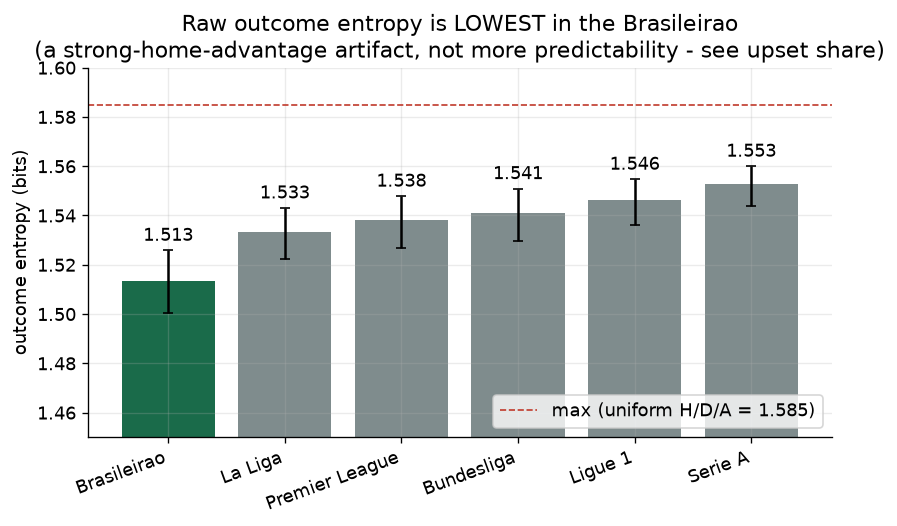

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
order = M['entropy'].sort_values().index
vals = M.loc[order, 'entropy']
err = np.vstack([vals - M.loc[order, 'entropy_lo'], M.loc[order, 'entropy_hi'] - vals])
bars = ax.bar(order, vals, yerr=err, color=bar_colors(order), capsize=3)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.axhline(np.log2(3), color=plotting.COLORS['accent'], ls='--', lw=1,
           label='max (uniform H/D/A = 1.585)')
ax.set(ylabel='outcome entropy (bits)', ylim=(1.45, 1.60),
       title='Raw outcome entropy is LOWEST in the Brasileirao\n(a strong-home-advantage artifact, not more predictability - see upset share)')
ax.legend(loc='lower right')
plt.xticks(rotation=20, ha='right')
plotting.save(fig, 'entropy')
plt.show()

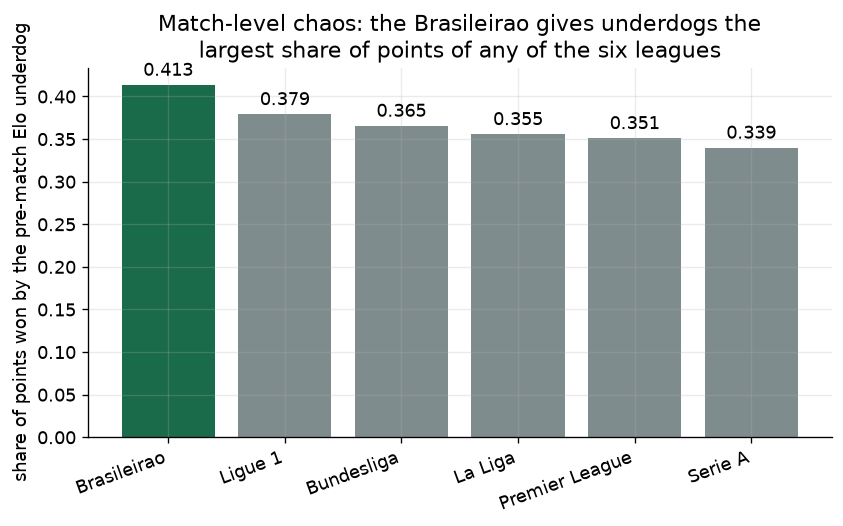

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
order = M['upset'].sort_values(ascending=False).index
vals = M.loc[order, 'upset']
bars = ax.bar(order, vals, color=bar_colors(order))
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set(ylabel='share of points won by the pre-match Elo underdog',
       title='Match-level chaos: the Brasileirao gives underdogs the\nlargest share of points of any of the six leagues')
plt.xticks(rotation=20, ha='right')
plotting.save(fig, 'upset_rate')
plt.show()

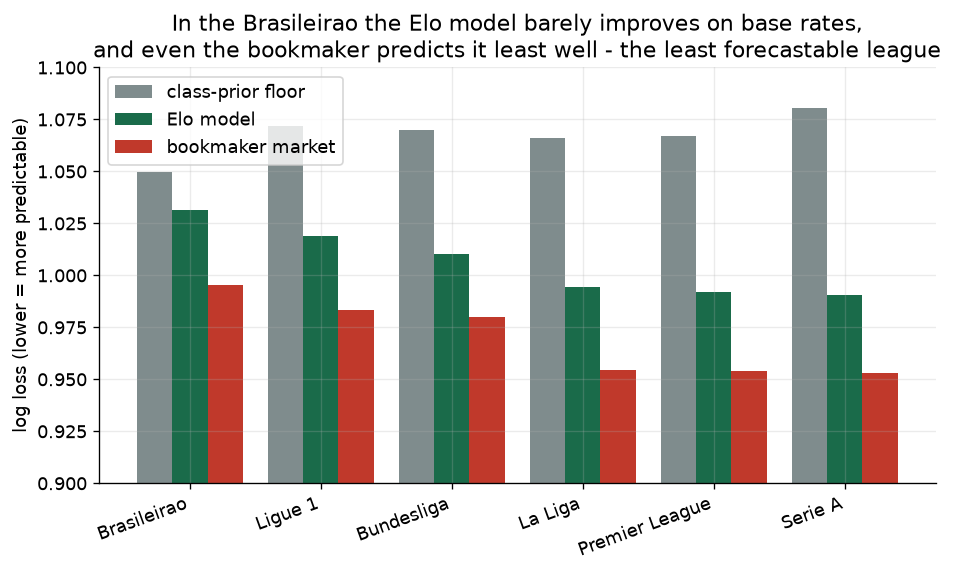

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = (M['floor_ll'] - M['model_ll']).sort_values().index   # least forecastable first
x = np.arange(len(order))
w = 0.27
ax.bar(x - w, M.loc[order, 'floor_ll'], w, label='class-prior floor',
       color=plotting.COLORS['muted'])
ax.bar(x, M.loc[order, 'model_ll'], w, label='Elo model',
       color=plotting.COLORS['main'])
ax.bar(x + w, M.loc[order, 'market_ll'], w, label='bookmaker market',
       color=plotting.COLORS['accent'])
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=20, ha='right')
ax.set(ylabel='log loss (lower = more predictable)', ylim=(0.90, 1.10),
       title='In the Brasileirao the Elo model barely improves on base rates,\nand even the bookmaker predicts it least well - the least forecastable league')
ax.legend()
plotting.save(fig, 'forecastability')
plt.show()

## Level 2 — But does the same giant win anyway?

A league can be a coin flip week to week and still crown the same champion every May. These three metrics test whether match-level chaos translates into an actually open competition.

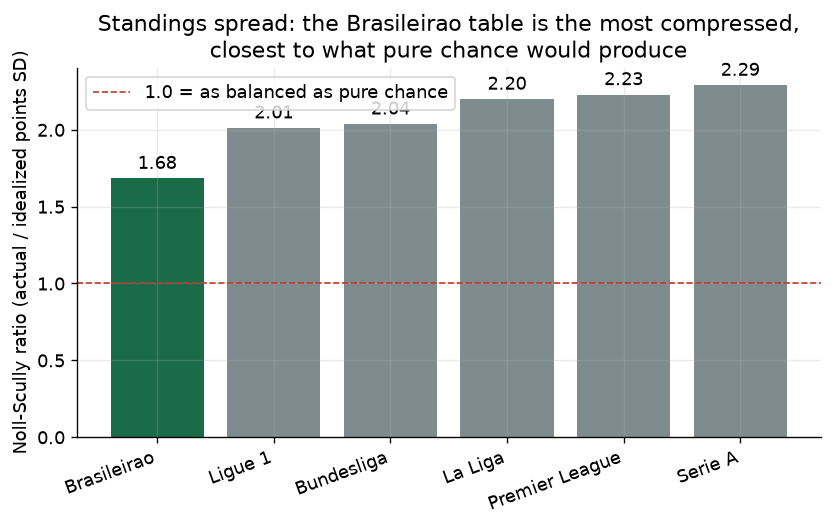

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
order = M['noll_scully'].sort_values().index
vals = M.loc[order, 'noll_scully']
bars = ax.bar(order, vals, color=bar_colors(order))
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.axhline(1.0, color=plotting.COLORS['accent'], ls='--', lw=1,
           label='1.0 = as balanced as pure chance')
ax.set(ylabel='Noll-Scully ratio (actual / idealized points SD)',
       title='Standings spread: the Brasileirao table is the most compressed,\nclosest to what pure chance would produce')
ax.legend()
plt.xticks(rotation=20, ha='right')
plotting.save(fig, 'noll_scully')
plt.show()

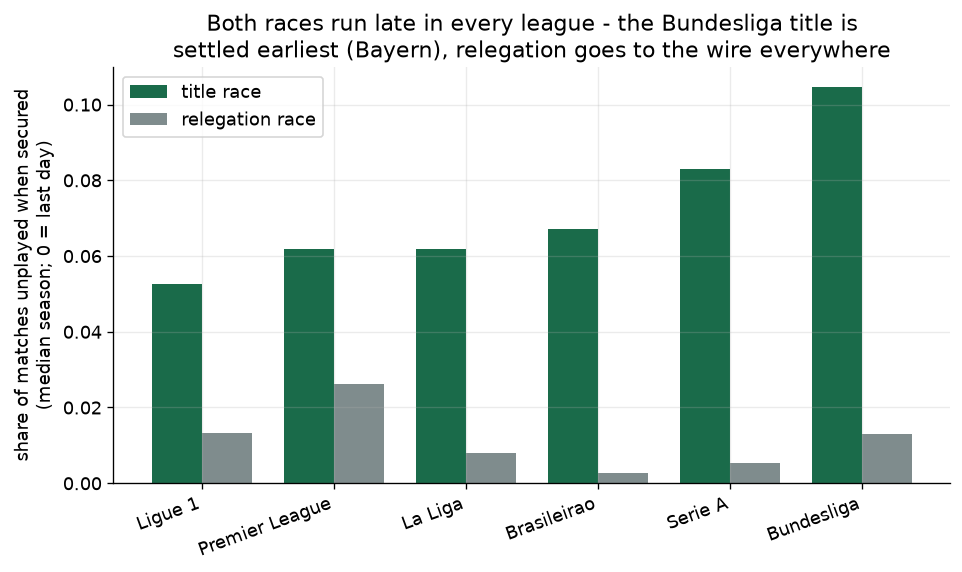

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = M['title_dec'].sort_values().index
x = np.arange(len(order))
w = 0.38
ax.bar(x - w/2, M.loc[order, 'title_dec'], w, label='title race',
       color=plotting.COLORS['main'])
ax.bar(x + w/2, M.loc[order, 'releg_dec'], w, label='relegation race',
       color=plotting.COLORS['muted'])
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=20, ha='right')
ax.set(ylabel='share of matches unplayed when secured\n(median season; 0 = last day)',
       title='Both races run late in every league - the Bundesliga title is\nsettled earliest (Bayern), relegation goes to the wire everywhere')
ax.legend()
plotting.save(fig, 'race_decidedness')
plt.show()

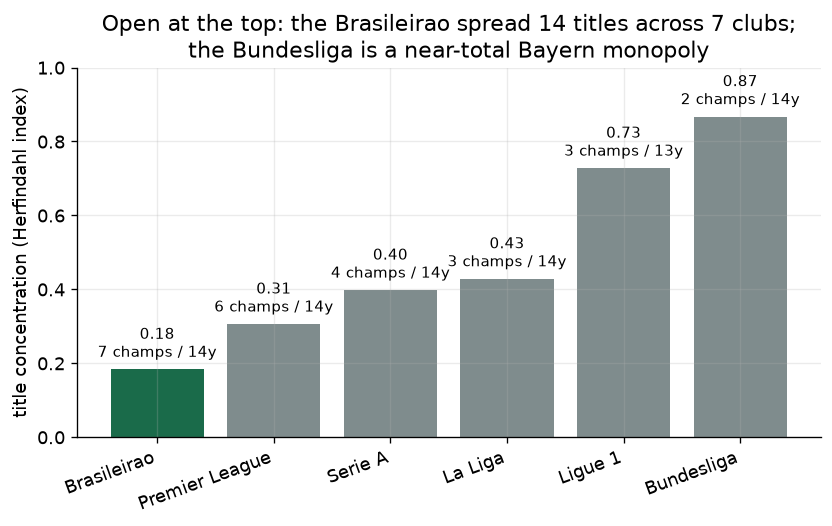

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
order = M['title_hhi'].sort_values().index
vals = M.loc[order, 'title_hhi']
bars = ax.bar(order, vals, color=bar_colors(order))
for bar, lg in zip(bars, order):
    n = int(M.loc[lg, 'distinct_champs'])
    yrs = int(M.loc[lg, 'seasons_used'])
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{M.loc[lg, "title_hhi"]:.2f}\n{n} champs / {yrs}y',
            ha='center', va='bottom', fontsize=9)
ax.set(ylabel='title concentration (Herfindahl index)', ylim=(0, 1.0),
       title='Open at the top: the Brasileirao spread 14 titles across 7 clubs;\nthe Bundesliga is a near-total Bayern monopoly')
plt.xticks(rotation=20, ha='right')
plotting.save(fig, 'title_concentration')
plt.show()

## Synthesis — match chaos vs open competition

Placing each league on a plane of *match-level chaos* (underdog points share) against *season-level openness* (1 − title HHI) tells the whole story in one chart. The spec framed three possible outcomes: **(a)** chaotic *and* open, **(b)** chaotic but still concentrated at the top, **(c)** not actually more chaotic than Europe. The data decides which.

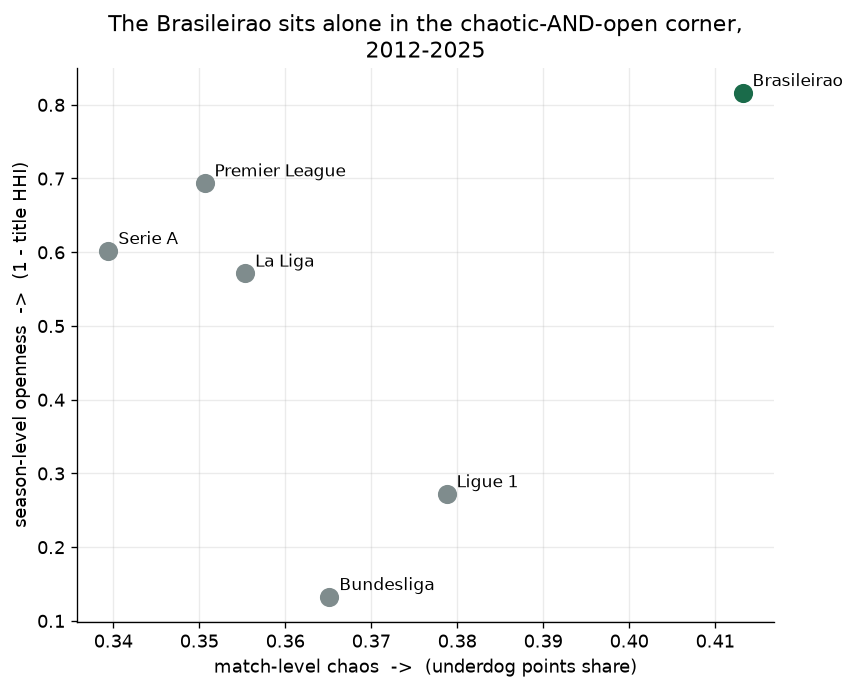

In [11]:
chaos = M['upset']
openness = 1 - M['title_hhi']
fig, ax = plt.subplots(figsize=(7.5, 6))
for lg in LEAGUES:
    ax.scatter(chaos[lg], openness[lg], s=110,
               color=plotting.COLORS['main'] if lg == 'Brasileirao'
               else plotting.COLORS['muted'], zorder=3)
    ax.annotate(lg, (chaos[lg], openness[lg]), xytext=(6, 4),
                textcoords='offset points', fontsize=10)
ax.set(xlabel='match-level chaos  ->  (underdog points share)',
       ylabel='season-level openness  ->  (1 - title HHI)',
       title='The Brasileirao sits alone in the chaotic-AND-open corner,\n2012-2025')
plotting.save(fig, 'chaos_vs_openness')
plt.show()

In [12]:
bra = M.loc['Brasileirao']
eu = M.drop('Brasileirao')
most_chaotic = bool(bra['upset'] > eu['upset'].max())
most_open = bool((1 - bra['title_hhi']) > (1 - eu['title_hhi']).max())
least_forecastable = bool((bra['floor_ll'] - bra['model_ll'])
                          < (eu['floor_ll'] - eu['model_ll']).min())
print(f"Brasileirao underdog points share {bra['upset']:.3f} "
      f"(Europe max {eu['upset'].max():.3f})  -> most chaotic: {most_chaotic}")
print(f"Brasileirao title openness {1 - bra['title_hhi']:.3f} "
      f"(Europe max {(1 - eu['title_hhi']).max():.3f})  -> most open: {most_open}")
print(f"Brasileirao Elo-over-floor gap {bra['floor_ll'] - bra['model_ll']:.4f} "
      f"(Europe min {(eu['floor_ll'] - eu['model_ll']).min():.4f})  "
      f"-> least forecastable: {least_forecastable}")

if most_chaotic and most_open:
    verdict = '(a) chaotic AND open: the Brasileirao is the most unpredictable at BOTH levels.'
elif most_chaotic and not most_open:
    verdict = '(b) chaotic but concentrated: chaotic weekends, yet the same giants win.'
else:
    verdict = '(c) not more chaotic than Europe once measured properly.'
print('\nVERDICT:', verdict)

Brasileirao underdog points share 0.413 (Europe max 0.379)  -> most chaotic: True
Brasileirao title openness 0.816 (Europe max 0.694)  -> most open: True
Brasileirao Elo-over-floor gap 0.0184 (Europe min 0.0531)  -> least forecastable: True

VERDICT: (a) chaotic AND open: the Brasileirao is the most unpredictable at BOTH levels.
